## Import 

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
import numpy as np

In [37]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float64)
y = mnist['target'].astype(int)

In [38]:
# หาภาพที่ label == 7
idx = np.where(y == 8)[0][0]     # index แรกของเลข 7
img = X[idx].reshape(28, 28)

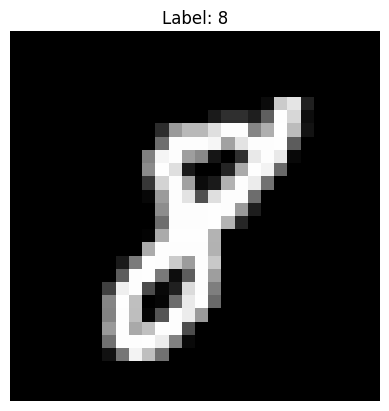

In [39]:
# แสดงภาพ
plt.imshow(img, cmap='gray')
plt.title(f"Label: {y[idx]}")
plt.axis('off')
plt.show()

In [43]:
mask = (y == 8)
X = X[mask]
y = y[mask]

## Data splitting

In [45]:
from sklearn.model_selection import train_test_split
# แบ่ง train/test ก่อน
X_temp, X_test = train_test_split(X, test_size=0.2, random_state=42)
X_train, X_val = train_test_split(X_temp, test_size=0.1, random_state=42)

In [50]:
X_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

## Normalization


In [51]:
X_train /= 255.0
X_val /= 255.0
X_test /= 255.0

## Data Loader

In [63]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

C:\Users\eieiz\AppData\Local\Temp\ipykernel_24012\213713434.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train, dtype=torch.float32)
C:\Users\eieiz\AppData\Local\Temp\ipykernel_24012\213713434.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val = torch.tensor(X_val, dtype=torch.float32)
C:\Users\eieiz\AppData\Local\Temp\ipykernel_24012\213713434.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test = torch.tensor(X_test, dtype=torch.float32)


In [64]:
train_loader = torch.utils.data.DataLoader(X_train, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(X_val, batch_size=128, shuffle=False)


## Model

In [65]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, latent_dim)
        self.fc_logvar = nn.Linear(400, latent_dim)
        self.fc_dec1 = nn.Linear(latent_dim, 400)
        self.fc_dec2 = nn.Linear(400, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc_dec1(z))
        return torch.sigmoid(self.fc_dec2(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar  

In [73]:
def vae_loss(x_recon, x, mu, logvar):
    BCE = F.binary_cross_entropy(x_recon, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD, BCE, KLD

In [75]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE(latent_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [76]:
train_losses, val_losses = [], []

In [77]:
for epoch in range(1, 51):
    model.train()
    total_train_loss = total_bce = total_kld = 0
    for x in train_loader:
        x = x.to(device)
        x_recon, mu, logvar = model(x)
        loss, bce, kld = vae_loss(x_recon, x, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()

    model.eval()
    total_val_loss = total_val_bce = total_val_kld = 0
    with torch.no_grad():
        for x in val_loader:
            x = x.to(device)
            x_recon, mu, logvar = model(x)
            loss, bce, kld = vae_loss(x_recon, x, mu, logvar)
            total_val_loss += loss.item()
            total_val_bce += bce.item()
            total_val_kld += kld.item()

    train_losses.append((total_train_loss, total_bce, total_kld))
    val_losses.append((total_val_loss, total_val_bce, total_val_kld))

    print(f"Epoch {epoch:2d} | Train Loss: {total_train_loss:.0f} | Val Loss: {total_val_loss:.0f}")


Epoch  1 | Train Loss: 905727 | Val Loss: 20862
Epoch  2 | Train Loss: 97190 | Val Loss: 6793
Epoch  3 | Train Loss: 57178 | Val Loss: 5696
Epoch  4 | Train Loss: 50921 | Val Loss: 5135
Epoch  5 | Train Loss: 45038 | Val Loss: 4497
Epoch  6 | Train Loss: 40873 | Val Loss: 4272
Epoch  7 | Train Loss: 35837 | Val Loss: 3793
Epoch  8 | Train Loss: 32646 | Val Loss: 3317
Epoch  9 | Train Loss: 29089 | Val Loss: 3129
Epoch 10 | Train Loss: 26572 | Val Loss: 2825
Epoch 11 | Train Loss: 24156 | Val Loss: 2554
Epoch 12 | Train Loss: 22302 | Val Loss: 2352
Epoch 13 | Train Loss: 21203 | Val Loss: 2235
Epoch 14 | Train Loss: 20176 | Val Loss: 2200
Epoch 15 | Train Loss: 19455 | Val Loss: 2083
Epoch 16 | Train Loss: 18979 | Val Loss: 2029
Epoch 17 | Train Loss: 18578 | Val Loss: 1999
Epoch 18 | Train Loss: 18277 | Val Loss: 1962
Epoch 19 | Train Loss: 18051 | Val Loss: 1951
Epoch 20 | Train Loss: 17869 | Val Loss: 1940
Epoch 21 | Train Loss: 17692 | Val Loss: 1921
Epoch 22 | Train Loss: 17572 | V

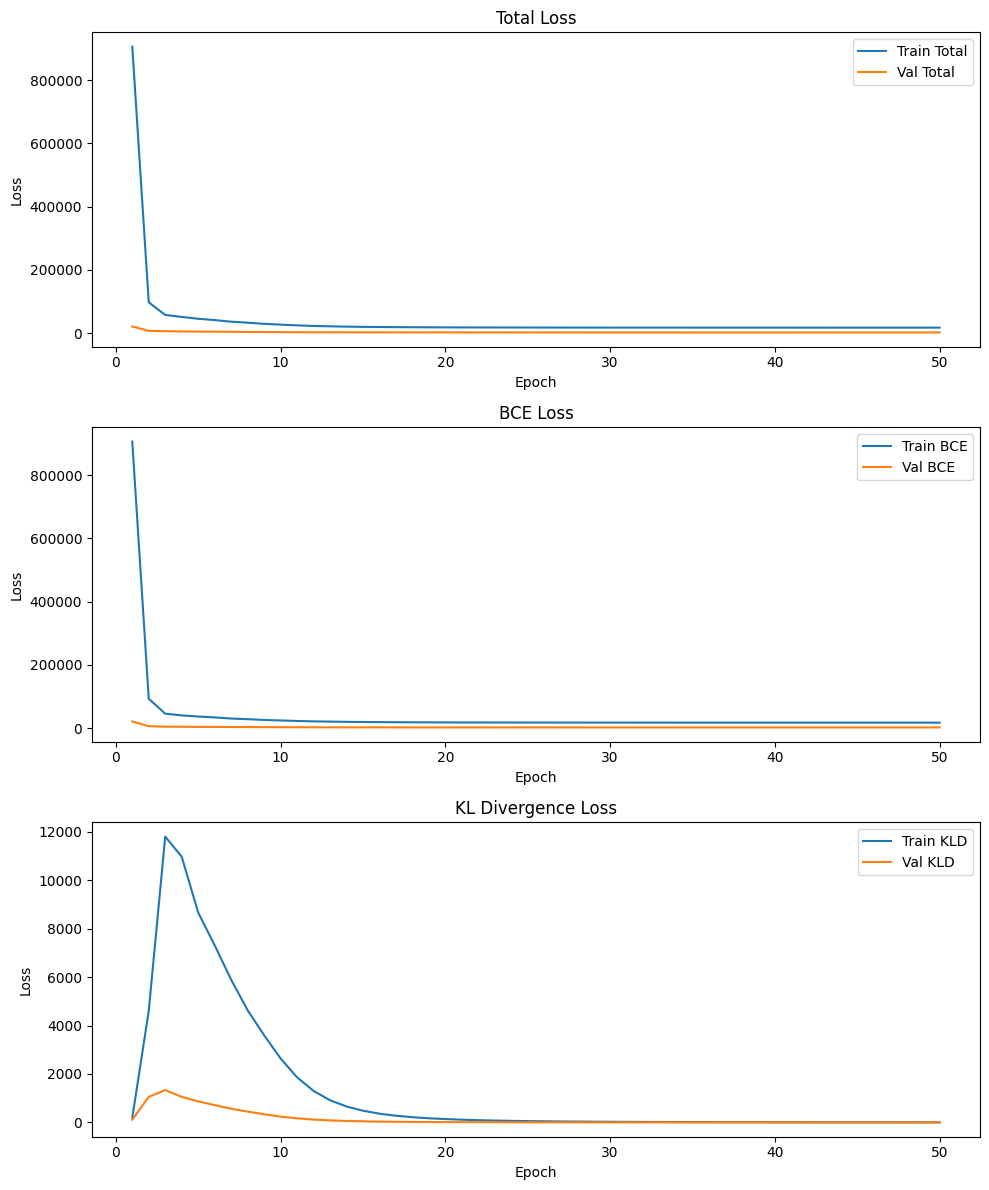

In [78]:
def plot_loss_separate(losses_train, losses_val):
    total_train, bce_train, kld_train = zip(*losses_train)
    total_val, bce_val, kld_val = zip(*losses_val)

    epochs = range(1, len(losses_train) + 1)

    fig, axs = plt.subplots(3, 1, figsize=(10, 12))

    # Total loss
    axs[0].plot(epochs, total_train, label='Train Total')
    axs[0].plot(epochs, total_val, label='Val Total')
    axs[0].set_title('Total Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].legend()

    # BCE loss
    axs[1].plot(epochs, bce_train, label='Train BCE')
    axs[1].plot(epochs, bce_val, label='Val BCE')
    axs[1].set_title('BCE Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].legend()

    # KL Divergence loss
    axs[2].plot(epochs, kld_train, label='Train KLD')
    axs[2].plot(epochs, kld_val, label='Val KLD')
    axs[2].set_title('KL Divergence Loss')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('Loss')
    axs[2].legend()

    plt.tight_layout()
    plt.show()

# เรียกใช้งานแทน plot_loss เดิม
plot_loss_separate(train_losses, val_losses)


In [84]:
X_test[11]

tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+

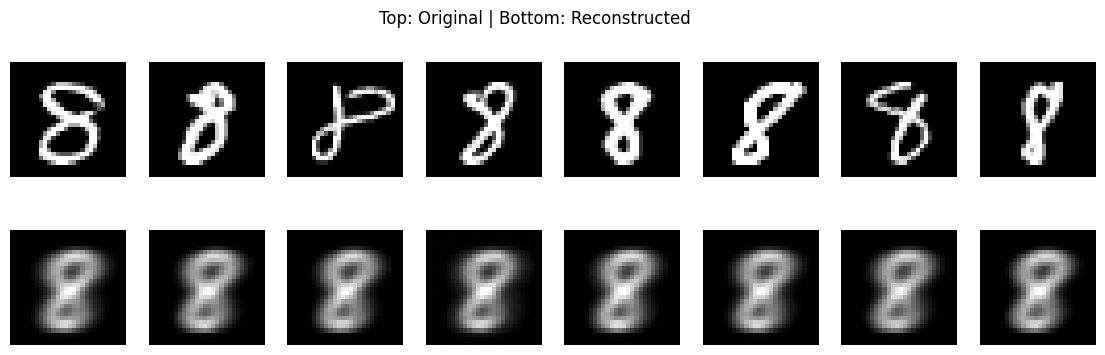

In [79]:
model.eval()
with torch.no_grad():
    x = X_test[:8].to(device)
    x_recon, _, _ = model(x)
    x = x.cpu().numpy().reshape(-1, 28, 28)
    x_recon = x_recon.cpu().numpy().reshape(-1, 28, 28)

    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    for i in range(8):
        axes[0, i].imshow(x[i], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(x_recon[i], cmap='gray')
        axes[1, i].axis('off')
    plt.suptitle("Top: Original | Bottom: Reconstructed")
    plt.show()